### 📊 Análise de Cirurgias CCP (Notebook Base) - 1º trimestre 2025

In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import plotly.express as px
import streamlit as st
# Ajuste visual
sns.set(style='whitegrid')

In [97]:
# 📥 Carregar cada mês em um DataFrame
#df_janeiro = pd.read_excel("Janeiro 2025.xlsx")
#df_fevereiro = pd.read_excel("Fevereiro 2025.xlsx")
#df_marco = pd.read_excel("Março 2025.xlsx")
df_abril = pd.read_excel("Abril 2025.xlsx")

# 🧩 Opcional: unir todos em um só DataFrame
df_total = pd.concat([df_abril], ignore_index=True)



In [98]:
# 👁️ Verificar os primeiros dados
df_total.head()

,DATA,PACIENTE,MV,CHEFE,RESIDENTE,CLINICA,SUS,CIRURGIA,VIDEO CIRURGIA,ANEST,ANESTESISTA,INICIO,FIM,CIRCULANTE
0,2025-04-02,NAIARA SOARES ANDRADE FERNANDES,216708,FRANCISCO ARAUJO DIAS (CRM - 154295),GIOVANA CRUZ CORSI (CRM - 168155),CP,SUS,LARINGECTOMIA TOTAL,NÃO,GERAL,MARA APARECIDA SUAVE (CRM - 85458),07:40:00,12:15:00,ALEX
1,2025-04-02,MANOEL PEREIRA DOS SANTOS,219287,ERICA ERINA FUKUYAMA (CRM - 72507),GIOVANA CRUZ CORSI (CRM - 168155),CP,SUS,FARINGECTOMIA PARCIAL,NÃO,GERAL,DEBORA VENTURA IZAR (CRM - 151521),15:10:00,16:50:00,HARETUSA
2,2025-04-02,ADRIANA MACEDO PONCIANO SOUZA,214997,ERICA ERINA FUKUYAMA (CRM - 72507),GIOVANA CRUZ CORSI (CRM - 168155),CP,SUS,TIREOIDECTOMIA PARCIAL,NÃO,GERAL,DEBORA VENTURA IZAR (CRM - 151521),12:35:00,14:35:00,HARETUSA
3,2025-04-03,MARIA AUXILIADORA L. DE SOUZA,213637,PABLO GABRIEL OCAMPO QUINTANA (CRM - 138741),DOMINIQUE AGUIAR BARBOSA PRADO (CRM - 210348),CP,SUS,TIREOIDECTOMIA PARCIAL DIR. + ISTMO,NÃO,GERAL,ANNA KARENY DE SOUZA NAZARETH (CRM - 160550),08:10:00,10:30:00,NICOLE
4,2025-04-03,FLAVIO DO NASCIMENTO,220281,PABLO GABRIEL OCAMPO QUINTANA (CRM - 138741),GIOVANA CRUZ CORSI (CRM - 168155),CP,SUS,TIREOIDECTOMIA PARCIAL DIR. + LINFADENECTOMIA ...,NÃO,GERAL,DEBORA VENTURA IZAR (CRM - 151521),08:10:00,10:20:00,LADY


In [99]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   DATA            58 non-null     datetime64[ns]
 1   PACIENTE        58 non-null     object        
 2   MV              58 non-null     int64         
 3   CHEFE           58 non-null     object        
 4   RESIDENTE       58 non-null     object        
 5   CLINICA         58 non-null     object        
 6   SUS             58 non-null     object        
 7   CIRURGIA        58 non-null     object        
 8   VIDEO CIRURGIA  58 non-null     object        
 9   ANEST           58 non-null     object        
 10  ANESTESISTA     57 non-null     object        
 11  INICIO          58 non-null     object        
 12  FIM             58 non-null     object        
 13  CIRCULANTE      58 non-null     object        
dtypes: datetime64[ns](1), int64(1), object(12)
memory usage: 6.5

In [100]:
df_total.isnull().sum()

DATA              0
PACIENTE          0
MV                0
CHEFE             0
RESIDENTE         0
CLINICA           0
SUS               0
CIRURGIA          0
VIDEO CIRURGIA    0
ANEST             0
ANESTESISTA       1
INICIO            0
FIM               0
CIRCULANTE        0
dtype: int64

In [101]:
#remover os espaços nas colunas
df_total.columns = df_total.columns.str.strip()


In [102]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   DATA            58 non-null     datetime64[ns]
 1   PACIENTE        58 non-null     object        
 2   MV              58 non-null     int64         
 3   CHEFE           58 non-null     object        
 4   RESIDENTE       58 non-null     object        
 5   CLINICA         58 non-null     object        
 6   SUS             58 non-null     object        
 7   CIRURGIA        58 non-null     object        
 8   VIDEO CIRURGIA  58 non-null     object        
 9   ANEST           58 non-null     object        
 10  ANESTESISTA     57 non-null     object        
 11  INICIO          58 non-null     object        
 12  FIM             58 non-null     object        
 13  CIRCULANTE      58 non-null     object        
dtypes: datetime64[ns](1), int64(1), object(12)
memory usage: 6.5

In [103]:
df_total['CLINICA'].value_counts()

CLINICA
CP    58
Name: count, dtype: int64

In [104]:
# selecionar apenas os casos da cp:

In [105]:
df_cp = df_total[df_total['CLINICA'] == 'CP']


In [106]:
#antigo
#df_cp.drop(columns=['VIDEO CIRURGIA', 'VIDEOCIRURGIA', 'SUS', 'Unnamed: 14', 'CLINICA'], inplace=True)
df_cp.drop(columns=['VIDEO CIRURGIA', 'SUS', 'CLINICA'], inplace=True)

In [107]:
df_cp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DATA         58 non-null     datetime64[ns]
 1   PACIENTE     58 non-null     object        
 2   MV           58 non-null     int64         
 3   CHEFE        58 non-null     object        
 4   RESIDENTE    58 non-null     object        
 5   CIRURGIA     58 non-null     object        
 6   ANEST        58 non-null     object        
 7   ANESTESISTA  57 non-null     object        
 8   INICIO       58 non-null     object        
 9   FIM          58 non-null     object        
 10  CIRCULANTE   58 non-null     object        
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 5.1+ KB


In [108]:
df_cp['CHEFE'].value_counts()

CHEFE
RAFAEL DE CICCO (CRM - 112733)                        17
FRANCISCO ARAUJO DIAS (CRM - 154295)                  12
PABLO GABRIEL OCAMPO QUINTANA (CRM - 138741)           9
MARCELO SOARES SCHALCH (CRM - 164050)                  6
ERICA ERINA FUKUYAMA (CRM - 72507)                     4
VICTOR BANDINI VIEIRA (CRM - 164000)                   4
JOAO                                                   3
SANDRA CARINA LOPEZ CALCINES (CRM - 210541)            2
GIOVANNA MARCELA VIEIRA DELLA NEGRA (CRM - 207914)     1
Name: count, dtype: int64

In [109]:
#deletar os médicos fora da clinica CP
#renomear os nomes duplicados

In [110]:
df_cp['CHEFE'] = df_cp['CHEFE'].replace({
    "SANDRA CARINA LOPEZ CALCINES (CRM - 210541) / GIOVANNA": "SANDRA CARINA LOPEZ CALCINES (CRM - 210541)"
})


In [111]:
df_cp = df_cp[~df_cp['CHEFE'].isin([
    "NIKKEI TAMURA (CRM - 97288)",
    "CARLOS ELIAS FRISTACHI (CRM - 44605)",
    "RODRIGO MACEDO DA SILVA (CRM - 112466)"
])]

In [112]:
cirurgias = df_cp['CIRURGIA'].dropna().unique().tolist()



In [113]:
for c in cirurgias:
    print(c)


LARINGECTOMIA TOTAL
FARINGECTOMIA PARCIAL
TIREOIDECTOMIA PARCIAL
TIREOIDECTOMIA PARCIAL DIR. + ISTMO
TIREOIDECTOMIA PARCIAL DIR. + LINFADENECTOMIA RECORRENCIAL
TRAQUEOSTOMIA
GLOSSECTOMIA PARCIAL ESQ. + ESVAZIAMENTO CERVICAL SUPRAOMOHIOIDEO
TIREOIDECTOMIA TOTAL
TIREOIDECTOMIA TOTAL + LINFADENECTOMIA RECORRENCIAL
ABLACAO DE NODULO POR MICROONDAS
LINFADENECTOMIA RADICAL ESQ. + ESVAZIMANETO CERVICAL RADICAL MODIFICADO BILATERALMENTE + RECONSTRUCAO DE NLR ESQ. + ANASTOMOSE TERMINO-TERMINAL
LARINGECTOMIA PARCIAL 
BIOPSIA DE MASSA PERI-LARINGEA DIR.
TROCA DE PROVOX
RESSECAO DE LESAO EM TRIGONO RETROMOLAR ESQ. + MANDIBULECTOMIA SEGMNETAR + RESSECCAO DE PELE + ECRM ESQ. + PAROTIDECTOMIA SUPERFICIAL ESQ. + RECONSTRUCAO COM RETALHO MICROCIRURGICO DE ANTEBRACO ESQ. + RECONSTRUCAO COM RETALHO DE PEITORAL ESQ. + ENXERTO EM AREA DOADORA DE RETALHO DE MSE + DRENAGEM COM PORTOVAC EN NSE E PEITORAL 
BIOPSIA DE PELE E PARTES MOLES
GLOSSECTOMIA PARCIAL
BIOPSIA DE MASSA EM REGIAO FRONTAL
RESSECCAO DE MULTI

In [114]:
#limpar os textos removendo espaços extras, apdronizando maisculas e minusculas:
df_cp['CIRURGIA'] = df_cp['CIRURGIA'].str.strip().str.upper()


In [115]:
# Agrupar as cirurgias que são iguais mas com nome diferente

In [ ]:
agrupamentos = {

    'TIREOIDECTOMIA TOTAL': [
            'TIREOIDECTOMIA TOTAL + LINFADENECTOMIA RECORRENCIAL', 
            'TIREOIDECTOMIA TOTAL (TOTALIZAÇÃO) + LINFADENECTOMIA RECORRENCIAL DIR.',
            'TIREOIDECTOMIA TOTAL',
            'TIREOIDECTOMIA TOTAL + ESVAZIAMENTO NIVEL VI DIR.',
            'TIREOIDECTOMIA TOTAL + EC NIVEL VI ESQ.',
            'TIREOIDECTOMIA TOTAL + ESVAZIAMENTO RECORRENCIAL DIR. + DRENAGEM COM PORTOVAC',
            'TIREIDECTOMIA TOTAL+ LINFADENECTOMIA RECORRENCIAL',
            'TIRERECTOMIA TOTAL EM ONCOLOGIA +LINFANDENECTOMIA CERVICAL RECORRENCIAL'
            'TIREOIDECTOMIA TOTAL + ESVAZIAMENTO CERVICAL NIVEIS II-VI ESQ.',
            'TIRERECTOMIA TOTAL EM ONCOLOGIA +LINFANDENECTOMIA CERVICAL RECORRENCIAL',
            'TIREOIDECTOMIA TOTAL + ESVAZIAMENTO CERVICAL NIVEIS II-VI ESQ.'
    ],
    
    'TIREOIDECTOMIA PARCIAL': [
            'TIREOIDECTOMIA PARCIAL DIR. + ISTMO',
            'TIREOIDECTOMIA PARCIAL',
            'TIREOIDECTOMIA PARCIAL DIR. + LINFADENECTOMIA NIVEL VI',
            'TIREOIDECTOMIA PARCIAL ESQ. + ISTMO', 'TIREOIDECTOMIA PARCAIL ESQ.',
            'TIREOIDECTOMIA PARCIAL ESQ. + LINFADENECTOMIA',
            'TIREOIDECTOMIA PARCIAL - VLP',
            'TIREOIDECTOMIA PARCIAL ESQ. + LINFADENECTOMIA RECORRENCIAL',
            'TIREOIDECTOMIA PARCIAL DIR. + ISTMO + LINFADENECTOMIA RECORRENCIAL'
    ],
    
    'ABLAÇÃO DE NODULO TIREOIDIANO': [
            'ABLAÇÃO DE NODULO TIREOIDIANO POR RADIOFREQUENCIA',
            'ABLAÇÃO DE NODULO POR RADIO FREQUENCIA TIREOIDECTOMIA PARCIAL',
            'TIREOIDECTOMIA PACIAL+ABLA DE NODULO POR MICROONDAS',
            'TIREOIDECTOMIA PARCIAL DIREITA +ABLAÇÃO DENODULO TIREOIDIANO POR RADIOFREQUENCIA',
            'TIREOIDECTOMIA PARCIAL ESQUERDA COM ABLAÇÃO DE NODULO POR MICROONDAS',
            'ABLACAO DE NODULO EM LOBO ESQ. (MICROWAVE)',
            'TIREOIDECTOMIA PARCIAL - RADIOFREQUÊNCIA'
            'ABLACAO DE NODULO POR RADIOFREQUENCIA'
            'ABLACAO DE NODULO POR RADIOFREQUENCIA',
            'TIREOIDECTOMIA PARCIAL - RADIOFREQUÊNCIA'
    ],

    'TIREOIDECTOMIA TOTAL + EC LATERAL': [
         'TIREOIDECTOMIA TOTAL + EC NIVEIS II A IV + VI + TQT + DRENAGEM COM PORTOVAC',
         'TIREOIDECTIA TOTAL EM ONC+ LINFADENECTOMIA RADICAL MODIFICA+LINFADENECTOMIA CERVICAL RECORRENCIAL NÍVEIS I,II, III, E IV ESQUERDA',
         'TIREOIDECTOMIA TOTAL + ESVAZIAMENTO CERVICAL NIVEIS II, III, IV, V E VI A ESQ.',
         'TIREOIDECTOMIA TOTAL + LINFADENECTOMIA RADICAL MODIFICADA BILATERAL + LINFADENECTOMIA RECORRENCIAL BILATERAL',
         'TIREOIDECTOMIA TOTAL + EC NIVEIS II, III, IV E VI DIR.',
         'TIREOIDECTOMIA TOTAL + ESVAZIAMENTO CERVICAL II-IV DIR.',
         'TIREOIDECTOMIA TOTAL + ESVAZIAMENTO CERVICAL II - IV BILATERAL + DREANGEM DE PORTOVAC'
    ],

    'GLOSSECTOMIA PARCIAL': [
        'GLOSSECTOMIA PARCIAL ANTERIOR',
        'GLOSSECTOMIA PARCIAL ESQ.',
        'GLOSSECTOMIA PARCIAL ESQ. + ESVAZIAMENTO CERVICAL SUPRA-OMOHIOIDEO ESQ. + RECONSTRUCAO COM RETALHO'
    ],

      'GLOSSECTOMIA TOTAL': [
        'GLOSSECTOMIA TOTAL + LINFADENECTOMIA RADICAL MODIFICADA ESQ. + RETALHO MIOCUTANEO',
        'GLOSSECTOMIA TOTAL'
    ],

    'PGM': [
        'PELGLOSSOMANDIBULECTOMIA+  LINFADENECTOMIA CERVICAL SUPRAO+TRAQUEOSTOMIA',
        'PELGLOSSOMANDIBULECTOMIA+ RECONSTRUÇÃO COM RETALHO MIO+TRAQUEOSTOMIA(MANDIBULECTOMIA SEGMENTAR E RAMO DE MANDIBULA A ESQUERDA+TORUS MAXILAR A ESQUERDA+RESSECÇÃO DE PAREDE LATERAL ESQ DE OROFARINGE+ESVAZIAMENTOCERVICAL I,II III IV ESQ +RETALHO',
        'PELVIGLOSSOMANDIBULECTOMIA'
        'PGM + RECONSTRUCAO C/ RETALHO MIOCUTANEO',
        'PGM + RECONSTRUCAO C/ RETALHO MIOCUTANEO',
        'PELVIGLOSSOMANDIBULECTOMIA'
    ],
  
  
    'TRAQUEOSTOMIA': [
        'TRAQUEOSTOMIA',
        'TRAQUEOSTOMIA DE URGENCIA + LARINGECTOMIA PARCIAL',
        'LARINGECTOMIA PARCIAL + TRAQUEOSTOMIA'
    ],

    'PROVOX': [
        'PASSAGEM DE PROTESE PROVOX',
        'TROCA DE PROVOX',
        'RECONSTRUCAO PARA FONACAO',
        'RECONTRUCAO PARA FONACAO',
        'RECONSTRUÇÃO PARA FONAÇÃO'
    
        
    ],

    'PAROTIDECTOMIA': [
       'PAROTIDECTOMIA SUPERFICIAL DIR. COM PRESERVACAO DE NERVO FACIAL (UTILIZADA MONITORIZACAO INTERMITENTE DO NERVO FACIAL)',
       'PAROTIDECTOMIA TOTAL + LINFADENECTOMIA RADICAL MODIFICADA UNILATERAL',
       'PAROTIDECTOMIA', 'PAROTIDECTOMIA TOTAL DIR.',
       'PAROTIDECTOMIA DIREITA TOTAL + RECONSTRUCAO COM RETALHO BILOBADO + RESSECCAO DE LESAO SUPRALABIAL A DIREITA',
       'PAROTIDECTOMIA TOTAL + RECONTRUCAO COM RETALHO BILOBADO',
       'PAROTIDECTOMIA TOTAL + LINFADENECTOMIA RADICAL MODIFICADA + RECONSTRUCAO PARA NERVO FACIAL',
       'PAROTIDECTOMIA TOTAL AMPLIADA A ESQ. + EC + RECONTRUCAO COM RETALHO SUPRACLAVICULAR + DRENAGEM COM PORTOVAC',
       'PAROTIDECTOMIA SUPERFICIAL DIR.'
    ],

    'LARINGECTOMIA TOTAL': [
       'LARINGECTOMIA TOTAL + EC II-IV BILATERAL + TIREPOIDECYOMIA TOTAL + FECHAMENTO + FECHAMENTO PRIMARIO DE FARINGE + PASSAGEM DE PROVOX + DRENAGEM CERVICAL COM PORTOVAC',
       'LARINGECTOMIA TOTAL + LINFADENECTOMIA RADICAL MODIFICCADA BILATERAL + PROTESE PARA FONACAO'
       'LARINGECTOMIA TOTAL + FARINGECTOMIA + ECRM BILATERAL + RECONTRUCAO DA FARINGE COM RETALHO PEITORAL MAIOR + PASSAGEM DE PROVOX'
       'LARINGECTOMIA TOTAL'
     ],



     'LARINGECTOMIA PARCIAL': [
       'LARINGECTOMIA PARCIAL', 'LARINGECTOMIA PARCIAL + TQT',
       'LARINGECTOMIA PARCIAL FRONTO-LATERAL DIR. + RETALHO MUSCULAR',
       'LARINGECTOMIA PARCIAL + TRAQUEOSTOMIA'
     ],
       
    'RESSECCAO DE TUMOR DE LABIO': [
       'RESSECCAO DE LESAO DE LABIO INFERIOR',
       'RESSECCAO DE LESAO EM LABIO INFERIOR + RECONSTRUCAO COM RETALHO',
       'RESSECCAO DE LESAO EM LABIO INFERIOR (CBC) + RECONSTRUCAO COM RETALHO FASCIOCUTANEO',
       'RESSECÇÃO DE LESÃO DE LABIO INFERIOR + RECONSTRUÇÃO C/ RETALHO',
       'RESSECCAO EM CUNHA DE LABIO',
       'RESSECCAO DE LESAO EM LABIO INFERIOR + RECONSTRUCAO COM RETALHO BILOBADO',
       'RESSECCAO DE LESAO EM LABIO INFERIOR'
     ],

    'FARINGECTOMIA PARCIAL': [
       'FARINGECTOMIA PARCIAL ESQ.', 'FARINGECTOMIA TOTAL',
       'FARINGECTOMIA + EC II A V A DIREITA + TQT + PASSAGEM DE SNE + DRENAGEM COM PORTOVAC',
       'FARINGECTOMIA PARCIAL',
       'BUCOFARINGECTOMIA ESQ. + LINFADENECTOMIA RADICAL MODIFICADA BILATERAL + RETALHO MIOFASCIOCUTANEO + TRAQUEOSTOMIA',
       'FARINGECTOMIA PARCIAL (AMIGDALECTOMIA ESQ.) + EC NIVEL II - IV ESQ. + SNE + DRENAGEM'
       'FARINGOLARINGECTOMIA PARCIAL',
       'FARINGECTOMIA PARCIAL (AMIGDALECTOMIA ESQ.) + EC NIVEL II - IV ESQ. + SNE + DRENAGEM',
       'FARINGOLARINGECTOMIA PARCIAL'
     ],

    'SEQUESTRECTOMIA': [
       'TRAQUEOSTOMIA + MANDIBULECTOMIA PARCIAL ESQ.',
       'MANDIBULESTOMIA PARCIAL ESQ.',
       'MANDIBULECTOMIA PARCIAL',
       'RESSECCAO DE OSTEORADIONECROSE DE CLAVICULA ESQUERDA',
        'MANDICULECTOMIA PARCIAL'
     ],

    'RESSECÇÃO DE SUBMANDIBULAR': [
      'RESSECCAO DE GLANDULA SUBMANDIBULAR'
      
     ],

    'RESSECÇÃO DE TUMOR DE PELE': [
       'EXCISÃO E SUTURA DE LESÃO NA PELE',
       'RESSECCAO DE LESOES DE PELE (TORAX)',
       'BIOPSIA DE PELE E PARTES MOLES',
       'RESSECÇAO DE LESÃO DE PELE EM COURO CABELUDO+ENXERTO INFRACLAVICULAR DIREITA',
       'EXCISÃO E SUTURA DE LESÃO NA PELE RESSECÇÃO DE LESÃO EM TEMPORA ESQUEDA+TARSORRAFIA+ENXERTO+CURATIVO BROWN',
       'RESECCAO DE LESAO DE PELE - TEMPORA ESQ.',
       'EXCISAO E SUTURA DE LESAO NA PELE',
       'EXTIRPACAO E SUSPRESSAO DE LESAO DE PELE',
       'AMPLIACAO DE MARGEM DE CBC EM REGIAO PARANSAL A DIR.',
       'BIOPSIA DE LESAO DE PARTES MOLES',
       'BIOPSIA DE PELE E PARTES MOLES',
       'BIÓPSIA DE LESÃO DE PARTES MOLES(BIOPSIA DE ASA NASAL',
       'AMPLIACAO DE MARGEM DE CBC EM REGIAO PARANSAL A DIR.',
       'AMPLIACAO DE MARGENS EM REGIAO RETROAURICULAR',
       'EXCISAO E SUTURA COM PLASTICA',
       'RESSECCAO DE LESAO PRE AURICULAR ESQ. + PAROTIEDCTOMIA SUPERFICAL COM PRESERVACAO DE NERVO FACIL + RETALHO DE AVANCO',
       'RESSECCAO DE LESAO CROSTOSA NASAL DIR.',
       'AMPLIACAO DE MARGENS EM REGIAO RETROAURICULAR',
       'BIÓPSIA DE LESÃO DE PARTES MOLES',
       'RESSECÇÃO DE LESÃO CERVICAL ANTERIOR'

      
     ],

    'ESVAZIAMENTO CERVICAL': [
       'ESVAZIAMENTO CERVICAL ESQ.',
       'ESVAZIAMENTO CERVICAL A ESQ. + DRENAGEM COM PORTVAC',
       'ESVAZIAMENTO CERVICAL RECORRENCIAL BILATERAL',
       'ESVAZIAMENTO CERVICAL UNILATERAL',
       'ESVAZIAMENTO CERVICAL II-IV BILATERAL + DRANAGEM COM PORTOVAC',
       'ESVAZIAMENTO RADICAL MODIFICADO UNILATERAL + ESVAZIAMENTO CERVICAL RECORRENCIAL UNILATERAL',
       'ESVAZIAMENTO CERVICAL DIR. II E IV + VI',
       'ESVAZIAMENTO CERVICAL DIR. + DRENAGEM DE PORTOVAC',
       'LINFADENECTOMIA RADICAL MODIFICA'
     ]

}


In [117]:
#função para pesquisar cirurgias

#df_cp[df_cp['CIRURGIA'].str.contains('CBC', case=False, na=False)]['CIRURGIA'].unique()


In [118]:
#CRIAR UMA COLUNA COM OS AGRUPAMENTOS

def mapear_grupo(cirurgia):
    for grupo, lista in agrupamentos.items():
        if cirurgia in lista:
            return grupo
    return 'OUTRAS'

df_cp['CIRURGIA_GRUPO'] = df_cp['CIRURGIA'].apply(mapear_grupo)


In [119]:
#df_cp['CIRURGIA_GRUPO'].value_counts()

In [120]:
#df_outros = df_cp[df_cp['CIRURGIA_GRUPO'] == 'OUTRAS']


In [121]:
#df_outros['CIRURGIA'].unique()


In [122]:
#df_outros['CIRURGIA'].value_counts()


In [123]:
df_cp['CIRURGIA_GRUPO'].value_counts()

CIRURGIA_GRUPO
OUTRAS                         30
TIREOIDECTOMIA TOTAL            7
TRAQUEOSTOMIA                   5
PROVOX                          4
FARINGECTOMIA PARCIAL           3
TIREOIDECTOMIA PARCIAL          3
RESSECÇÃO DE TUMOR DE PELE      3
LARINGECTOMIA PARCIAL           2
RESSECCAO DE TUMOR DE LABIO     1
Name: count, dtype: int64

#### Corrigir as horas para formato brasileiro e gerar coluna duração em minutos e horas

In [124]:
# Função para corrigir turno (03:00 → 15:00, se necessário)
def corrigir_turno(hora):
    if pd.isna(hora):
        return None

    hora_str = str(hora).strip()

    # Se já for datetime ou time, transforma em string no formato HH:MM:SS
    if isinstance(hora, pd._libs.tslibs.timestamps.Timestamp):
        hora_str = hora.strftime('%H:%M:%S')

    try:
        h = int(hora_str[:2])
        if h < 7:
            nova_hora = str(h + 12).zfill(2) + hora_str[2:]
        else:
            nova_hora = hora_str
        return pd.to_datetime(nova_hora, format='%H:%M:%S', errors='coerce').time()
    except:
        return None  # Se falhar (ex: string inválida), retorna None

# Aplicar a função nas colunas de horário
df_cp['INICIO'] = df_cp['INICIO'].apply(corrigir_turno)
df_cp['FIM'] = df_cp['FIM'].apply(corrigir_turno)

# Unir com a coluna de DATA para gerar datetime completo
df_cp['INICIO'] = pd.to_datetime(df_cp['DATA'].astype(str) + ' ' + df_cp['INICIO'].astype(str), errors='coerce')
df_cp['FIM'] = pd.to_datetime(df_cp['DATA'].astype(str) + ' ' + df_cp['FIM'].astype(str), errors='coerce')

# Calcular duração em minutos
df_cp['DURACAO_MIN'] = (df_cp['FIM'] - df_cp['INICIO']).dt.total_seconds() / 60

In [125]:
df_cp['DURACAO_HORAS'] = df_cp['DURACAO_MIN'] / 60

In [126]:
df_cp.shape

(58, 14)

# 🤝 - Concluido a limpeza dos dados

In [127]:
df_cp_EAD = df_cp.copy()

In [128]:
df_cp_EAD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   DATA            58 non-null     datetime64[ns]
 1   PACIENTE        58 non-null     object        
 2   MV              58 non-null     int64         
 3   CHEFE           58 non-null     object        
 4   RESIDENTE       58 non-null     object        
 5   CIRURGIA        58 non-null     object        
 6   ANEST           58 non-null     object        
 7   ANESTESISTA     57 non-null     object        
 8   INICIO          58 non-null     datetime64[ns]
 9   FIM             58 non-null     datetime64[ns]
 10  CIRCULANTE      58 non-null     object        
 11  CIRURGIA_GRUPO  58 non-null     object        
 12  DURACAO_MIN     58 non-null     float64       
 13  DURACAO_HORAS   58 non-null     float64       
dtypes: datetime64[ns](3), float64(2), int64(1), object(8)
memory

In [129]:
df_cp_EAD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   DATA            58 non-null     datetime64[ns]
 1   PACIENTE        58 non-null     object        
 2   MV              58 non-null     int64         
 3   CHEFE           58 non-null     object        
 4   RESIDENTE       58 non-null     object        
 5   CIRURGIA        58 non-null     object        
 6   ANEST           58 non-null     object        
 7   ANESTESISTA     57 non-null     object        
 8   INICIO          58 non-null     datetime64[ns]
 9   FIM             58 non-null     datetime64[ns]
 10  CIRCULANTE      58 non-null     object        
 11  CIRURGIA_GRUPO  58 non-null     object        
 12  DURACAO_MIN     58 non-null     float64       
 13  DURACAO_HORAS   58 non-null     float64       
dtypes: datetime64[ns](3), float64(2), int64(1), object(8)
memory

## 1️⃣ Contagem de cirurgias

In [130]:
# Contagem dos grupos
grupo_counts = df_cp_EAD['CIRURGIA_GRUPO'].value_counts().reset_index()
grupo_counts.columns = ['Grupo de Cirurgia', 'Quantidade']

# Gráfico com barras horizontais e cores distintas
fig = px.bar(
    grupo_counts,
    x='Quantidade',
    y='Grupo de Cirurgia',
    orientation='h',
    color='Grupo de Cirurgia',  # Garante cores distintas
    title='Frequência por Grupo de Cirurgia',
    text='Quantidade',
    color_discrete_sequence=px.colors.qualitative.Safe  # Ou outra paleta como 'Plotly', 'Pastel', etc.
)

fig.update_layout(
    xaxis_title='Número de Casos',
    yaxis_title='Grupo de Cirurgia',
    template='simple_white',
    yaxis={'categoryorder': 'total ascending'},
    showlegend=True
)

fig.show()



In [131]:
df_cp_EAD['CIRURGIA_GRUPO'].value_counts()

CIRURGIA_GRUPO
OUTRAS                         30
TIREOIDECTOMIA TOTAL            7
TRAQUEOSTOMIA                   5
PROVOX                          4
FARINGECTOMIA PARCIAL           3
TIREOIDECTOMIA PARCIAL          3
RESSECÇÃO DE TUMOR DE PELE      3
LARINGECTOMIA PARCIAL           2
RESSECCAO DE TUMOR DE LABIO     1
Name: count, dtype: int64

#### Agrupar em doenças:

In [132]:
mapa_grupo_mestre = {
    # TIREOIDE
    'TIREOIDECTOMIA TOTAL': 'Tireoide',
    'TIREOIDECTOMIA PARCIAL': 'Tireoide',
    'TIREOIDECTOMIA TOTAL + EC LATERAL': 'Tireoide',
    'ABLAÇÃO DE NODULO TIREOIDIANO': 'Tireoide',

    # GLÂNDULA SALIVAR
    'PAROTIDECTOMIA': 'Glândula salivar',
    'RESSECÇÃO DE SUBMANDIBULAR': 'Glândula salivar',

    # FARINGE
    'FARINGECTOMIA PARCIAL': 'Faringe',

    # PELE
    'RESSECÇÃO DE TUMOR DE PELE': 'Pele',

    # LARINGE
    'LARINGECTOMIA PARCIAL': 'Laringe',
    'LARINGECTOMIA TOTAL': 'Laringe',
    'TRAQUEOSTOMIA': 'Laringe',
    'PROVOX': 'Laringe',

    # BOCA
    'GLOSSECTOMIA PARCIAL': 'Boca',
    'GLOSSECTOMIA TOTAL': 'Boca',
    'RESSECCAO DE TUMOR DE LABIO': 'Boca',
    'PGM': 'Boca',

    # OUTRAS
    'SEQUESTRECTOMIA': 'Outras',
    'ESVAZIAMENTO CERVICAL': 'Outras',
    'OUTRAS': 'Outras'
}



In [133]:
df_cp_EAD['GRUPO_MESTRE'] = df_cp_EAD['CIRURGIA_GRUPO'].map(mapa_grupo_mestre).fillna('Outras')


In [134]:
df_cp_EAD['GRUPO_MESTRE'].value_counts()

GRUPO_MESTRE
Outras      30
Laringe     11
Tireoide    10
Faringe      3
Pele         3
Boca         1
Name: count, dtype: int64

In [135]:
# Contagem por grupo mestre
grupo_mestre_counts = df_cp_EAD['GRUPO_MESTRE'].value_counts().reset_index()
grupo_mestre_counts.columns = ['Grupo Mestre', 'Quantidade']

# Gráfico
fig = px.bar(
    grupo_mestre_counts,
    x='Quantidade',
    y='Grupo Mestre',
    orientation='h',
    color='Grupo Mestre',
    title='Distribuição por Patologia',
    text='Quantidade',
    color_discrete_sequence=px.colors.qualitative.Plotly
)

fig.update_layout(
    xaxis_title='Número de Cirurgias',
    yaxis_title='Grupo Mestre',
    template='simple_white',
    yaxis={'categoryorder': 'total ascending'},
    showlegend=False
)

fig.show()


### 2️⃣ Tempo de cirurgia

In [136]:
df_cp_EAD['DURACAO_HORAS'].describe()

count    58.000000
mean      2.345115
std       2.381215
min       0.166667
25%       0.770833
50%       1.875000
75%       3.000000
max      15.333333
Name: DURACAO_HORAS, dtype: float64

<Axes: >

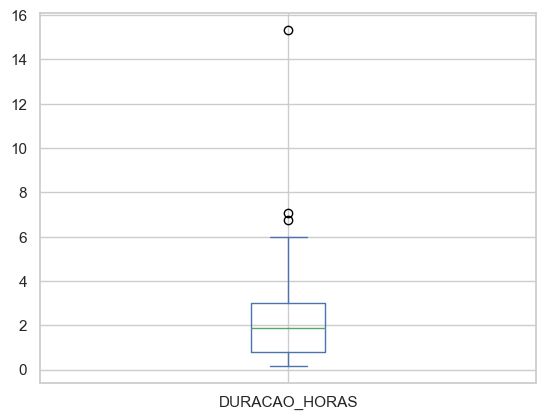

In [137]:
df_cp_EAD['DURACAO_HORAS'].plot.box()

In [138]:
cirurgias_maior_5h = df_cp_EAD[df_cp_EAD['DURACAO_HORAS'] > 5]



In [139]:
cirurgias_maior_5h


,DATA,PACIENTE,MV,CHEFE,RESIDENTE,CIRURGIA,ANEST,ANESTESISTA,INICIO,FIM,CIRCULANTE,CIRURGIA_GRUPO,DURACAO_MIN,DURACAO_HORAS,GRUPO_MESTRE
11,2025-04-04,JOAO GOMES DE MELO FILHO,205040,RAFAEL DE CICCO (CRM - 112733),DOMINIQUE AGUIAR BARBOSA PRADO (CRM - 210348),LINFADENECTOMIA RADICAL ESQ. + ESVAZIMANETO CE...,GERAL,MARA APARECIDA SUAVE (CRM - 85458),2025-04-04 08:00:00,2025-04-04 14:00:00,NICOLE,OUTRAS,360.0,6.000000,Outras
15,2025-04-07,CLARICE PEREIRA DA ROCHA MATTOS,220979,MARCELO SOARES SCHALCH (CRM - 164050),DOMINIQUE AGUIAR BARBOSA PRADO (CRM - 210348),RESSECAO DE LESAO EM TRIGONO RETROMOLAR ESQ. +...,GERAL,DEBORA VENTURA IZAR (CRM - 151521),2025-04-07 07:50:00,2025-04-07 23:10:00,NICOLE,OUTRAS,920.0,15.333333,Outras
22,2025-04-11,NIVALDO CORREIA ROCHA SANTOS,221715,RAFAEL DE CICCO (CRM - 112733),DOMINIQUE AGUIAR BARBOSA PRADO (CRM - 210348),LARINGECTOMIA TOTAL + FARINGECTOMIA + ECRM BIL...,GERAL,MARA APARECIDA SUAVE (CRM - 85458),2025-04-11 08:05:00,2025-04-11 14:50:00,SUSANE,OUTRAS,405.0,6.750000,Outras
26,2025-04-11,GRACIELIA DA SILVA MOREIRA,216703,VICTOR BANDINI VIEIRA (CRM - 164000),GIOVANA CRUZ CORSI (CRM - 168155),TIREOIDECTOMIA TOTAL + ESVAZIAMENTO CERVICAL N...,GERAL,FERNANDO DOS SANTOS PAULO (CRM - 87612),2025-04-11 11:55:00,2025-04-11 19:00:00,LADY,OUTRAS,425.0,7.083333,Outras


In [140]:
cirurgias_maior_5h[['CHEFE', 'CIRURGIA', 'DURACAO_HORAS']]


,CHEFE,CIRURGIA,DURACAO_HORAS
11,RAFAEL DE CICCO (CRM - 112733),LINFADENECTOMIA RADICAL ESQ. + ESVAZIMANETO CE...,6.000000
15,MARCELO SOARES SCHALCH (CRM - 164050),RESSECAO DE LESAO EM TRIGONO RETROMOLAR ESQ. +...,15.333333
22,RAFAEL DE CICCO (CRM - 112733),LARINGECTOMIA TOTAL + FARINGECTOMIA + ECRM BIL...,6.750000
26,VICTOR BANDINI VIEIRA (CRM - 164000),TIREOIDECTOMIA TOTAL + ESVAZIAMENTO CERVICAL N...,7.083333


### 3️⃣ Produtividade por assistente

In [141]:
df_cp_EAD['CHEFE'].value_counts()

CHEFE
RAFAEL DE CICCO (CRM - 112733)                        17
FRANCISCO ARAUJO DIAS (CRM - 154295)                  12
PABLO GABRIEL OCAMPO QUINTANA (CRM - 138741)           9
MARCELO SOARES SCHALCH (CRM - 164050)                  6
ERICA ERINA FUKUYAMA (CRM - 72507)                     4
VICTOR BANDINI VIEIRA (CRM - 164000)                   4
JOAO                                                   3
SANDRA CARINA LOPEZ CALCINES (CRM - 210541)            2
GIOVANNA MARCELA VIEIRA DELLA NEGRA (CRM - 207914)     1
Name: count, dtype: int64

In [142]:

# Contagem por chefe
chefe_counts = df_cp_EAD['CHEFE'].value_counts().reset_index()
chefe_counts.columns = ['Chefe', 'Quantidade']

# Gráfico
fig = px.bar(
    chefe_counts,
    x='Quantidade',
    y='Chefe',
    orientation='h',
    color='Chefe',
    title='Número de Cirurgias por Chefe',
    text='Quantidade',
    color_discrete_sequence=px.colors.qualitative.Plotly
)

fig.update_layout(
    xaxis_title='Número de Cirurgias',
    yaxis_title='Chefe Responsável',
    template='simple_white',
    yaxis={'categoryorder': 'total ascending'},
    showlegend=False
)

fig.show()


In [143]:
df_cp_EAD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   DATA            58 non-null     datetime64[ns]
 1   PACIENTE        58 non-null     object        
 2   MV              58 non-null     int64         
 3   CHEFE           58 non-null     object        
 4   RESIDENTE       58 non-null     object        
 5   CIRURGIA        58 non-null     object        
 6   ANEST           58 non-null     object        
 7   ANESTESISTA     57 non-null     object        
 8   INICIO          58 non-null     datetime64[ns]
 9   FIM             58 non-null     datetime64[ns]
 10  CIRCULANTE      58 non-null     object        
 11  CIRURGIA_GRUPO  58 non-null     object        
 12  DURACAO_MIN     58 non-null     float64       
 13  DURACAO_HORAS   58 non-null     float64       
 14  GRUPO_MESTRE    58 non-null     object        
dtypes: datet

In [144]:
df_cp_EAD['MV'].head()

0    216708
1    219287
2    214997
3    213637
4    220281
Name: MV, dtype: int64

In [145]:
#CRIAR COLUNAS QUE FALTAM

In [146]:
df_cp_EAD2 = df_cp_EAD.copy()

In [147]:
df_cp_EAD2['COMPLICACAO'] = ""  # ou pd.NA, se preferir nulo
df_cp_EAD2['QUAL'] = ""
df_cp_EAD2['TEMPO_INTERNACAO_HORAS'] = pd.NA
df_cp_EAD2['TEMPO_INTERNACAO_DIAS'] = pd.NA
df_cp_EAD2['OBITO'] = ""
df_cp_EAD2['REINTERNACAO_NAO_PROGRAMADA'] = ""


In [148]:
#deletar o nome dos pacientes para gerar o arquivo para subir no github
df_cp_EAD2.drop(columns=['PACIENTE'], inplace=True)

In [149]:
#Produzir planilha nova para alimentar o dashboard
df_cp_EAD2.to_excel("C:/Users/franc/Desktop/cirurgias_cp_1ºtrim.xlsx", index=False)
